In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

# Data Loading

In [3]:
df=pd.read_csv("data/SkyCity Auckland Restaurants & Bars.csv")

In [4]:
df.head()

,CuisineType,RestaurantID,RestaurantName,Segment,Subregion,GrowthFactor,AOV,MonthlyOrders,InStoreOrders,InStoreRevenue,...,DeliveryCostPerOrder,SD_DeliveryTotalCost,InStoreNetProfit,UberEatsNetProfit,DoorDashNetProfit,SelfDeliveryNetProfit,InStoreShare,UE_share,DD_share,SD_share
0,Burgers,25731,Urban Burgers House,Cafe,North Shore,1.03,43.97,668,197,8662.09,...,3.25,458.25,3682.14,1352.45,752.78,2177.19,0.42,0.45,0.25,0.3
1,Burgers,25123,Urban Burgers Diner,QSR,South Auckland,1.05,40.45,1388,259,10476.55,...,4.72,1600.08,3605.72,1318.61,731.99,3119.38,0.23,0.45,0.25,0.3
2,Burgers,25177,King Burgers Eatery,Cafe,West Auckland,1.04,40.03,1717,524,20975.72,...,3.25,1163.50,7810.95,1555.90,863.42,4172.99,0.44,0.45,0.25,0.3
3,Burgers,25540,Classic Burgers Tavern,QSR,North Shore,1.03,36.28,1083,216,7836.48,...,0.89,231.40,2546.02,-72.25,-40.20,2833.26,0.25,0.45,0.25,0.3
4,Burgers,25258,Lucky Burgers Bistro,Cafe,South Auckland,1.05,34.34,1230,261,8962.74,...,2.66,774.06,3093.09,226.17,125.53,2674.56,0.27,0.45,0.25,0.3


In [5]:
df.shape

(1696, 30)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1696 entries, 0 to 1695
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CuisineType            1696 non-null   str    
 1   RestaurantID           1696 non-null   int64  
 2   RestaurantName         1696 non-null   str    
 3   Segment                1696 non-null   str    
 4   Subregion              1696 non-null   str    
 5   GrowthFactor           1696 non-null   float64
 6   AOV                    1696 non-null   float64
 7   MonthlyOrders          1696 non-null   int64  
 8   InStoreOrders          1696 non-null   int64  
 9   InStoreRevenue         1696 non-null   float64
 10  UberEatsOrders         1696 non-null   int64  
 11  DoorDashOrders         1696 non-null   int64  
 12  SelfDeliveryOrders     1696 non-null   int64  
 13  UberEatsRevenue        1696 non-null   float64
 14  DoorDashRevenue        1696 non-null   float64
 15  SelfDeliveryRev

# Data Quality Check

In [7]:
missing_values=df.isnull().sum()
missing_values[missing_values>0]


Series([], dtype: int64)

In [8]:
duplicate_values=df.duplicated().sum()
print(duplicate_values)


0


# Summary statistics

In [9]:
df.describe()

,RestaurantID,GrowthFactor,AOV,MonthlyOrders,InStoreOrders,InStoreRevenue,UberEatsOrders,DoorDashOrders,SelfDeliveryOrders,UberEatsRevenue,...,DeliveryCostPerOrder,SD_DeliveryTotalCost,InStoreNetProfit,UberEatsNetProfit,DoorDashNetProfit,SelfDeliveryNetProfit,InStoreShare,UE_share,DD_share,SD_share
count,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,...,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000
mean,25848.500000,1.028255,38.516887,1190.527123,218.980542,8422.392730,471.906250,257.155071,242.485259,18170.030360,...,3.119363,755.783886,2257.321557,152.410425,89.105100,2139.315118,0.225654,0.486763,0.265242,0.247995
std,489.737345,0.022700,4.459408,422.334848,149.758619,5851.233352,171.781981,92.605301,129.950736,6959.241673,...,1.344848,541.323056,1618.692119,2340.125579,1271.832584,1875.802610,0.126977,0.067685,0.034294,0.094582
min,25001.000000,0.990000,29.790000,441.000000,13.000000,412.360000,142.000000,81.000000,60.000000,5050.950000,...,0.890000,53.400000,155.000000,-7787.110000,-4349.940000,-983.280000,0.030000,0.350000,0.200000,0.150000
25%,25424.750000,1.030000,34.787500,827.000000,101.000000,3904.342500,331.000000,179.750000,146.000000,12524.745000,...,1.770000,358.662500,1122.580000,-1291.512500,-718.617500,807.867500,0.110000,0.450000,0.250000,0.150000
50%,25848.500000,1.040000,38.340000,1182.000000,178.000000,6791.430000,456.000000,249.000000,212.000000,17548.980000,...,3.250000,601.800000,1785.720000,676.685000,369.665000,1742.945000,0.210000,0.500000,0.250000,0.200000
75%,26272.250000,1.050000,42.495000,1525.000000,307.000000,11550.755000,602.000000,326.250000,306.250000,23016.000000,...,4.130000,1005.030000,2848.090000,1581.570000,862.602500,2995.282500,0.320000,0.550000,0.300000,0.300000
max,26696.000000,1.050000,47.230000,2337.000000,819.000000,35356.230000,937.000000,466.000000,702.000000,43038.960000,...,5.310000,3653.280000,10474.680000,8275.570000,4514.880000,13222.100000,0.550000,0.600000,0.300000,0.450000


# Business Overview Section

In [10]:
print("Unique Restaurants:",df['RestaurantName'].nunique())
print("Cuisine Types:",df['CuisineType'].nunique())
print("Segments:",df['Segment'].nunique())
print("Subregions:",df['Subregion'].nunique())


Unique Restaurants: 256
Cuisine Types: 8
Segments: 4
Subregions: 4


# Exploratory Data Analytics

## Univariate Analysis

### Monthly Order Distribution

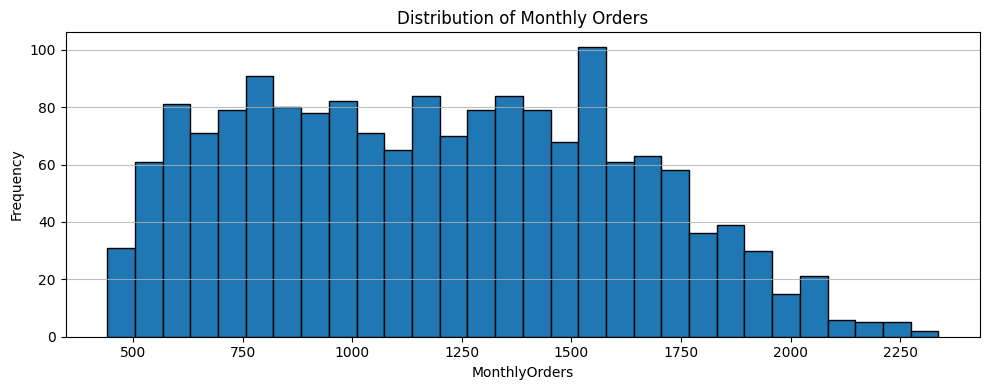

In [11]:
plt.figure(figsize=(10,4))
plt.hist(df["MonthlyOrders"],bins=30,edgecolor='black')
plt.title("Distribution of Monthly Orders")
plt.xlabel("MonthlyOrders")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.8)
plt.tight_layout()
plt.show()

### AOV Distribution

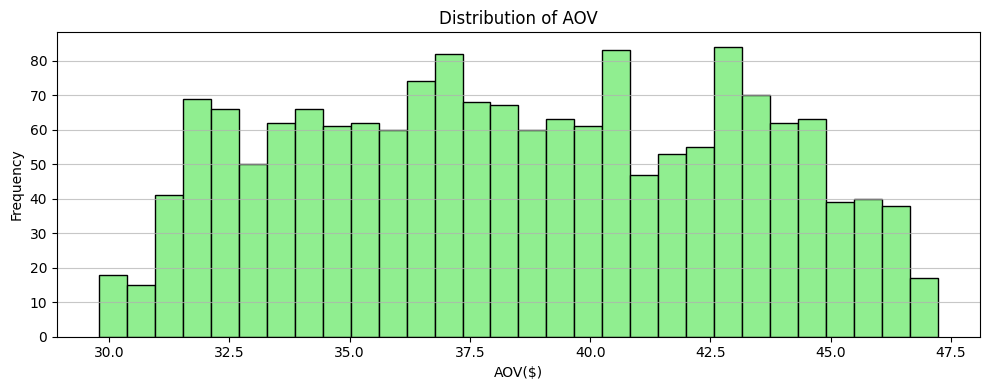

In [12]:
plt.figure(figsize=(10,4))
plt.hist(df["AOV"],bins=30,color='lightgreen',edgecolor='black')
plt.title("Distribution of AOV")
plt.xlabel("AOV($)")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.7)

plt.tight_layout()
plt.show()

### Growth Factor Distribution

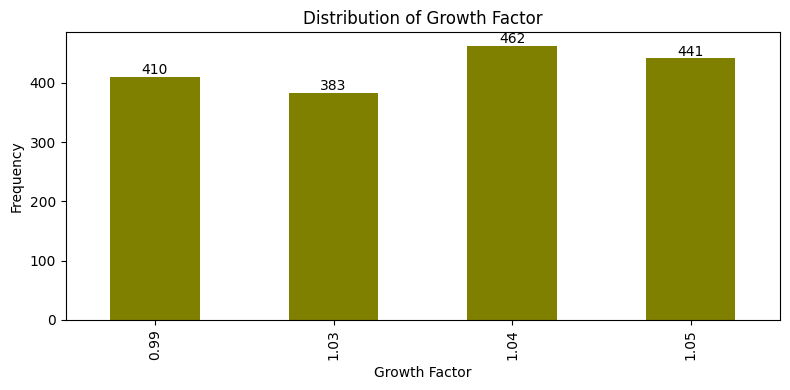

In [13]:
growth_counts=df["GrowthFactor"].value_counts().sort_index()
ax=growth_counts.plot(kind='bar',figsize=(8,4),color='olive')
for i,v in enumerate(growth_counts):
    ax.text(i,v+5,str(v),ha='center')
plt.title("Distribution of Growth Factor")
plt.xlabel("Growth Factor")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Outlier Detection

### For Monthly Orders

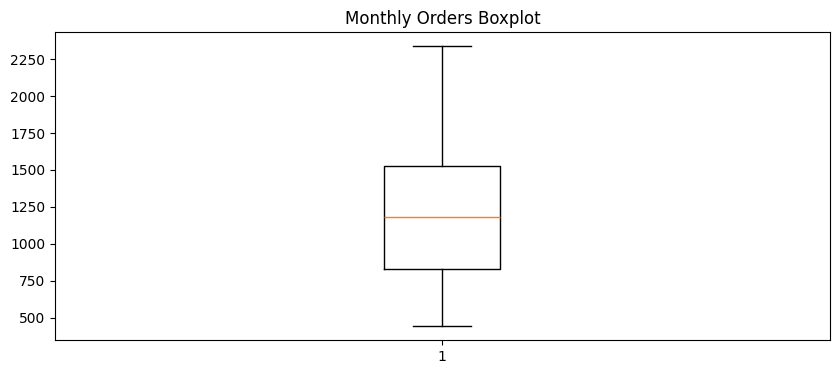

In [14]:
plt.figure(figsize=(10,4))
plt.boxplot(df['MonthlyOrders'])
plt.title('Monthly Orders Boxplot')
plt.show()

### For AOV

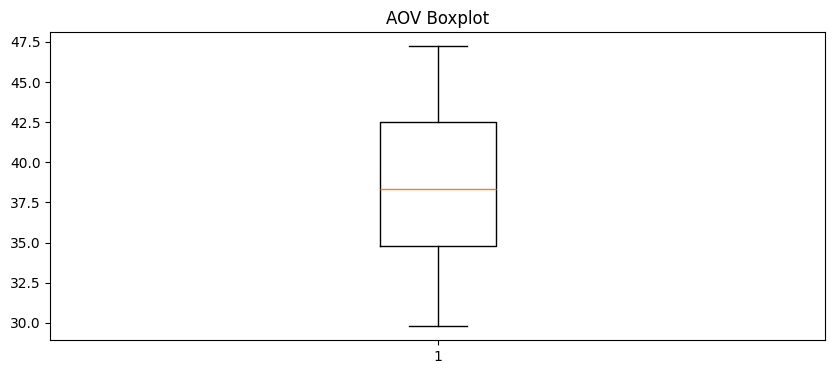

In [15]:
plt.figure(figsize=(10,4))
plt.boxplot(df['AOV'])
plt.title('AOV Boxplot')
plt.show()

## Revenue Analysis by Cuisine

### Total Revenue

In [16]:
df['TotalRevenue']=(
    df['InStoreRevenue']
    + df['UberEatsRevenue']
    + df['DoorDashRevenue']
    + df['SelfDeliveryRevenue']
).round(0)


In [17]:
df.head()

,CuisineType,RestaurantID,RestaurantName,Segment,Subregion,GrowthFactor,AOV,MonthlyOrders,InStoreOrders,InStoreRevenue,...,SD_DeliveryTotalCost,InStoreNetProfit,UberEatsNetProfit,DoorDashNetProfit,SelfDeliveryNetProfit,InStoreShare,UE_share,DD_share,SD_share,TotalRevenue
0,Burgers,25731,Urban Burgers House,Cafe,North Shore,1.03,43.97,668,197,8662.09,...,458.25,3682.14,1352.45,752.78,2177.19,0.42,0.45,0.25,0.3,29372.0
1,Burgers,25123,Urban Burgers Diner,QSR,South Auckland,1.05,40.45,1388,259,10476.55,...,1600.08,3605.72,1318.61,731.99,3119.38,0.23,0.45,0.25,0.3,56145.0
2,Burgers,25177,King Burgers Eatery,Cafe,West Auckland,1.04,40.03,1717,524,20975.72,...,1163.50,7810.95,1555.90,863.42,4172.99,0.44,0.45,0.25,0.3,68732.0
3,Burgers,25540,Classic Burgers Tavern,QSR,North Shore,1.03,36.28,1083,216,7836.48,...,231.40,2546.02,-72.25,-40.20,2833.26,0.25,0.45,0.25,0.3,39291.0
4,Burgers,25258,Lucky Burgers Bistro,Cafe,South Auckland,1.05,34.34,1230,261,8962.74,...,774.06,3093.09,226.17,125.53,2674.56,0.27,0.45,0.25,0.3,42238.0


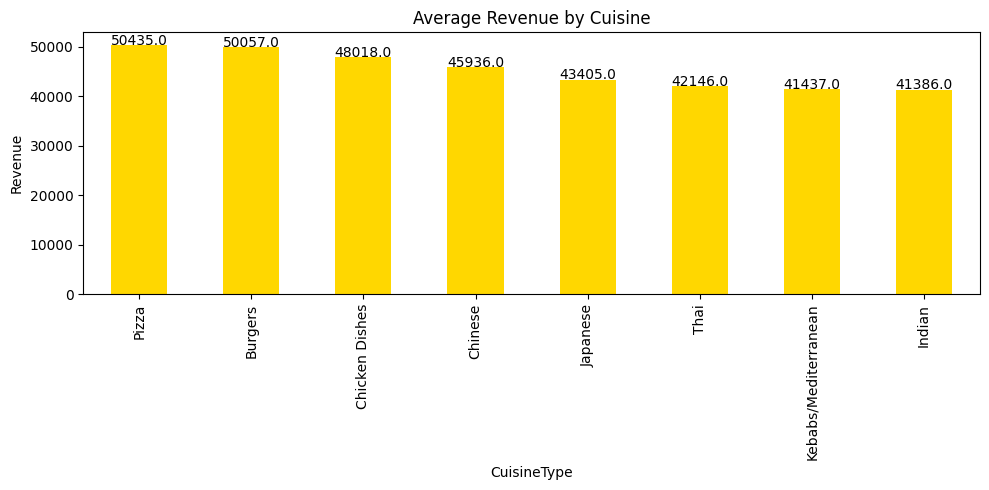

In [18]:
cuisine_revenue=(
    df.groupby('CuisineType')['TotalRevenue']
    .mean()
    .sort_values(ascending=False).round(0)
)
ax=cuisine_revenue.plot(
    kind='bar',
    figsize=(10,5),
    color='gold'
)
for i,v in enumerate(cuisine_revenue):
    ax.text(i,v+10,str(v),ha='center')
plt.title('Average Revenue by Cuisine')
plt.ylabel('Revenue')
plt.xlabel('CuisineType')
plt.tight_layout()
plt.show()

## Profit Analysis by Segment

### Total Profit

In [19]:
df['TotalProfit']=(
     df['InStoreNetProfit']
    + df['UberEatsNetProfit']
    + df['DoorDashNetProfit']
    + df['SelfDeliveryNetProfit']
).round(0)



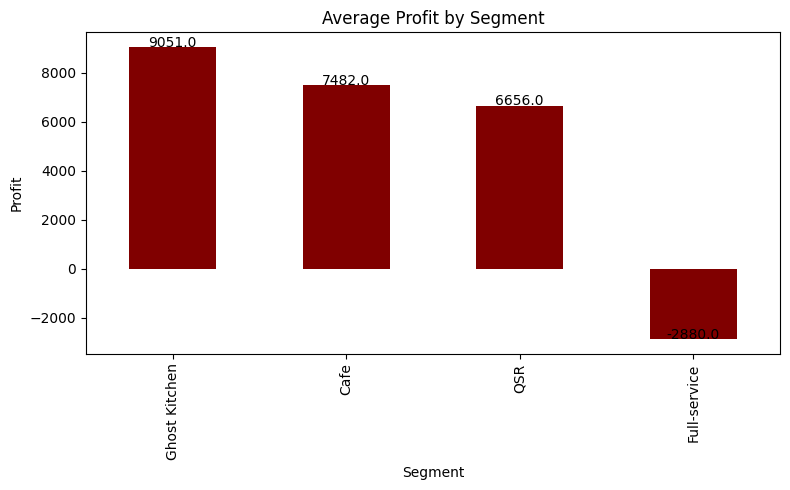

In [20]:
segment_profit=(
    df.groupby('Segment')['TotalProfit']
    .mean()
    .sort_values(ascending=False).round(0)
)
ax=segment_profit.plot(
    kind='bar',
    figsize=(8,5),
    color='maroon'
)
for i,v in enumerate(segment_profit):
    ax.text(i,v+5,str(v),ha='center')
plt.title('Average Profit by Segment')
plt.ylabel('Profit')
plt.xlabel('Segment')
plt.tight_layout()
plt.show()

## Correlation Heatmap

In [21]:
import plotly.io as pio
pio.renderers.default ='browser'
corr=df.select_dtypes(include=['int64','float64']).corr()
fig= px.imshow(
     corr,text_auto=True,
     aspect='auto',
     title='Correlation Heatmap')
fig.show()

## Channel Mix
### Average Channel Shares

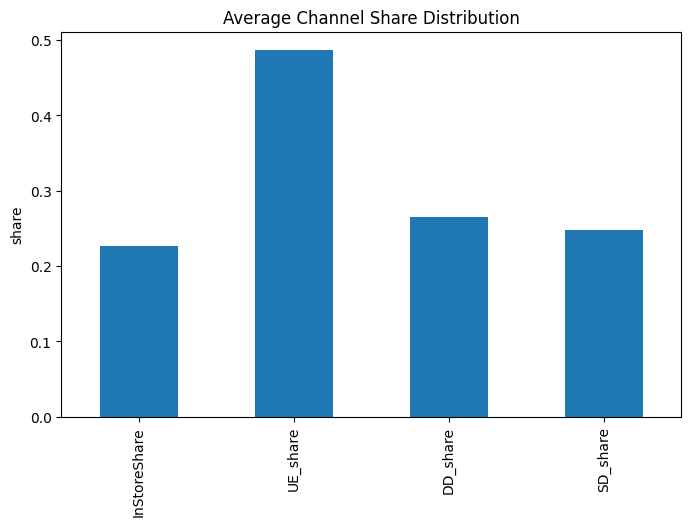

In [22]:
channel_shares=df[['InStoreShare','UE_share','DD_share','SD_share']].mean().round(3)
ax=channel_shares.plot(kind='bar',figsize=(8,5))
plt.title('Average Channel Share Distribution')
plt.ylabel('share')
plt.show()



### Total Orders by Channels

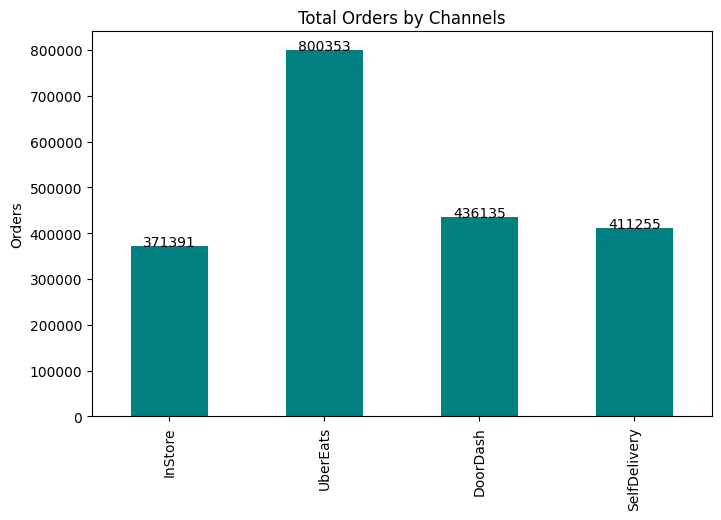

In [23]:
orders={'InStore':df['InStoreOrders'].sum(),
        'UberEats':df['UberEatsOrders'].sum(),
        'DoorDash':df['DoorDashOrders'].sum(),
        'SelfDelivery':df['SelfDeliveryOrders'].sum()}
orders_df=pd.Series(orders)
orders_df
ax=orders_df.plot(kind='bar',figsize=(8,5),color='teal')
for i,v in enumerate(orders_df):
    ax.text(i,v+5,str(v),ha='center')

plt.title('Total Orders by Channels')
plt.ylabel('Orders')
plt.show()


### Total Revenue by Channels

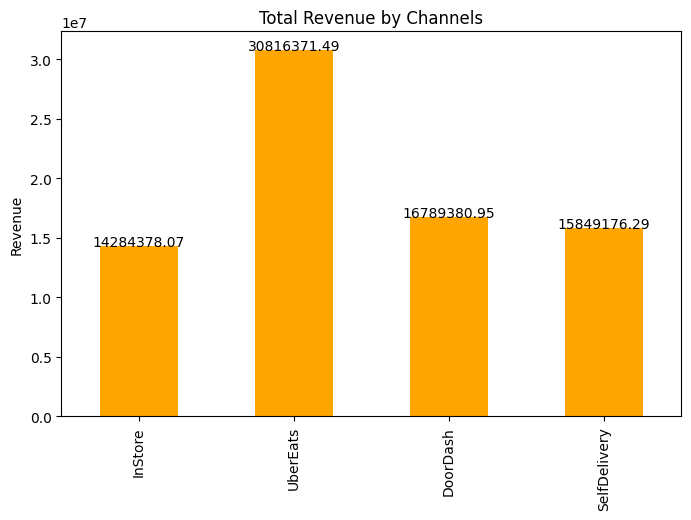

InStore         14284378.07
UberEats        30816371.49
DoorDash        16789380.95
SelfDelivery    15849176.29
dtype: float64

In [24]:
revenues={'InStore':df['InStoreRevenue'].sum(),
        'UberEats':df['UberEatsRevenue'].sum(),
        'DoorDash':df['DoorDashRevenue'].sum(),
        'SelfDelivery':df['SelfDeliveryRevenue'].sum()}
revenues_df=pd.Series(revenues).round(2)
ax=revenues_df.plot(kind='bar',figsize=(8,5),color='orange')
for i,v in enumerate(revenues_df):
    ax.text(i,v+5,str(v),ha='center')

plt.title('Total Revenue by Channels')
plt.ylabel('Revenue')
plt.show()
revenues_df


### Total profit by Channels

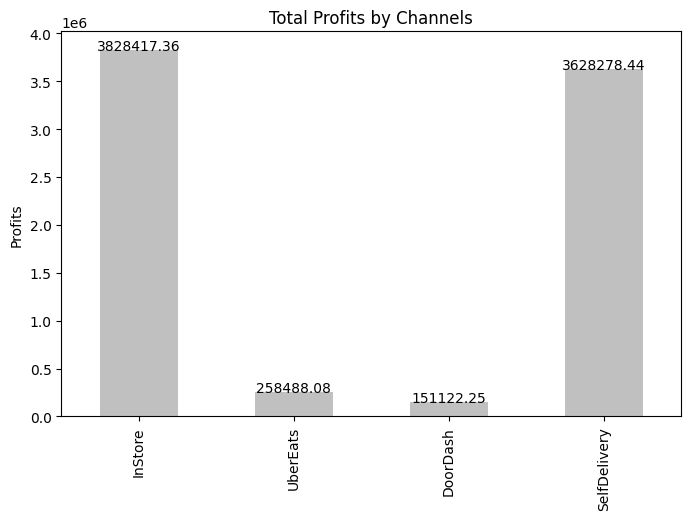

InStore         3828417.36
UberEats         258488.08
DoorDash         151122.25
SelfDelivery    3628278.44
dtype: float64

In [25]:
profits={'InStore':df['InStoreNetProfit'].sum(),
        'UberEats':df['UberEatsNetProfit'].sum(),
        'DoorDash':df['DoorDashNetProfit'].sum(),
        'SelfDelivery':df['SelfDeliveryNetProfit'].sum()}
profits_df=pd.Series(profits).round(2)
ax=profits_df.plot(kind='bar',figsize=(8,5),color='silver')
for i,v in enumerate(profits_df):
    ax.text(i,v+5,str(v),ha='center')

plt.title('Total Profits by Channels')
plt.ylabel('Profits')
plt.show()
profits_df

### Channel Share Distribution 

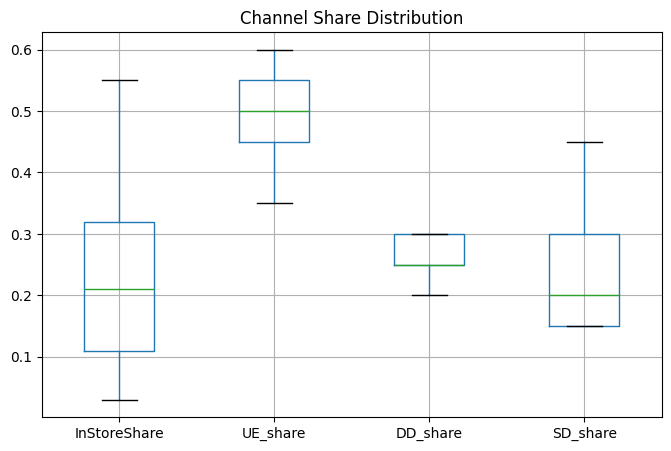

       InStoreShare     UE_share     DD_share     SD_share
count   1696.000000  1696.000000  1696.000000  1696.000000
mean       0.225654     0.486763     0.265242     0.247995
std        0.126977     0.067685     0.034294     0.094582
min        0.030000     0.350000     0.200000     0.150000
25%        0.110000     0.450000     0.250000     0.150000
50%        0.210000     0.500000     0.250000     0.200000
75%        0.320000     0.550000     0.300000     0.300000
max        0.550000     0.600000     0.300000     0.450000


In [26]:
plt.figure(figsize=(8,5))
df[['InStoreShare','UE_share','DD_share','SD_share']].boxplot()
plt.title('Channel Share Distribution')
plt.show()
print(df[['InStoreShare','UE_share','DD_share','SD_share']].describe())
